# MODELO BINOMIAL

[None 'ORIENTE' 'SUROESTE' 'BAJO CAUCA' 'URABÁ' 'VALLE DE ABURRÁ' 'NORTE'
 'NORDESTE' 'MAGDALENA MEDIO' 'OCCIDENTE' 'Suroeste' 'Valle de Aburrá'
 'Occidente' 'Norte' 'Urabá' 'Oriente' 'Nordeste' 'Magdalena Medio'
 'Bajo Cauca']
Optimization terminated successfully.
         Current function value: 0.433792
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Inund   No. Observations:                 2529
Model:                          Logit   Df Residuals:                     2520
Method:                           MLE   Df Model:                            8
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.3742
Time:                        12:25:08   Log-Likelihood:                -1097.1
converged:                       True   LL-Null:                       -1752.9
Covariance Type:            nonrobust   LLR p-value:                6.721e-278
                 coef    std err      

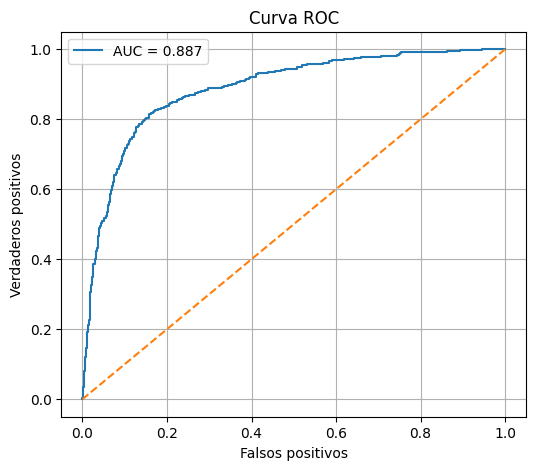


Matriz de confusión:
        Pred 0  Pred 1
Real 0    1033     226
Real 1     219    1051


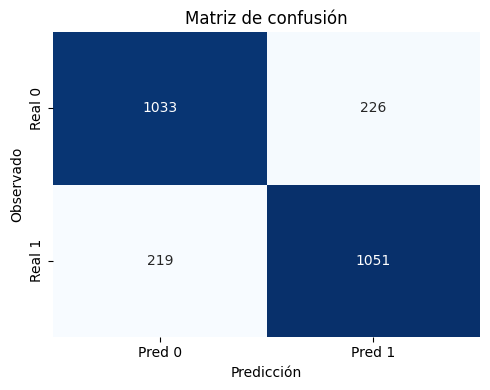

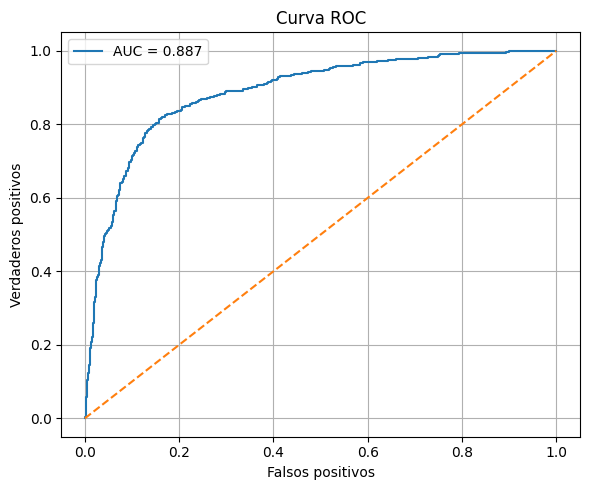

AUC: 0.8870757318957052


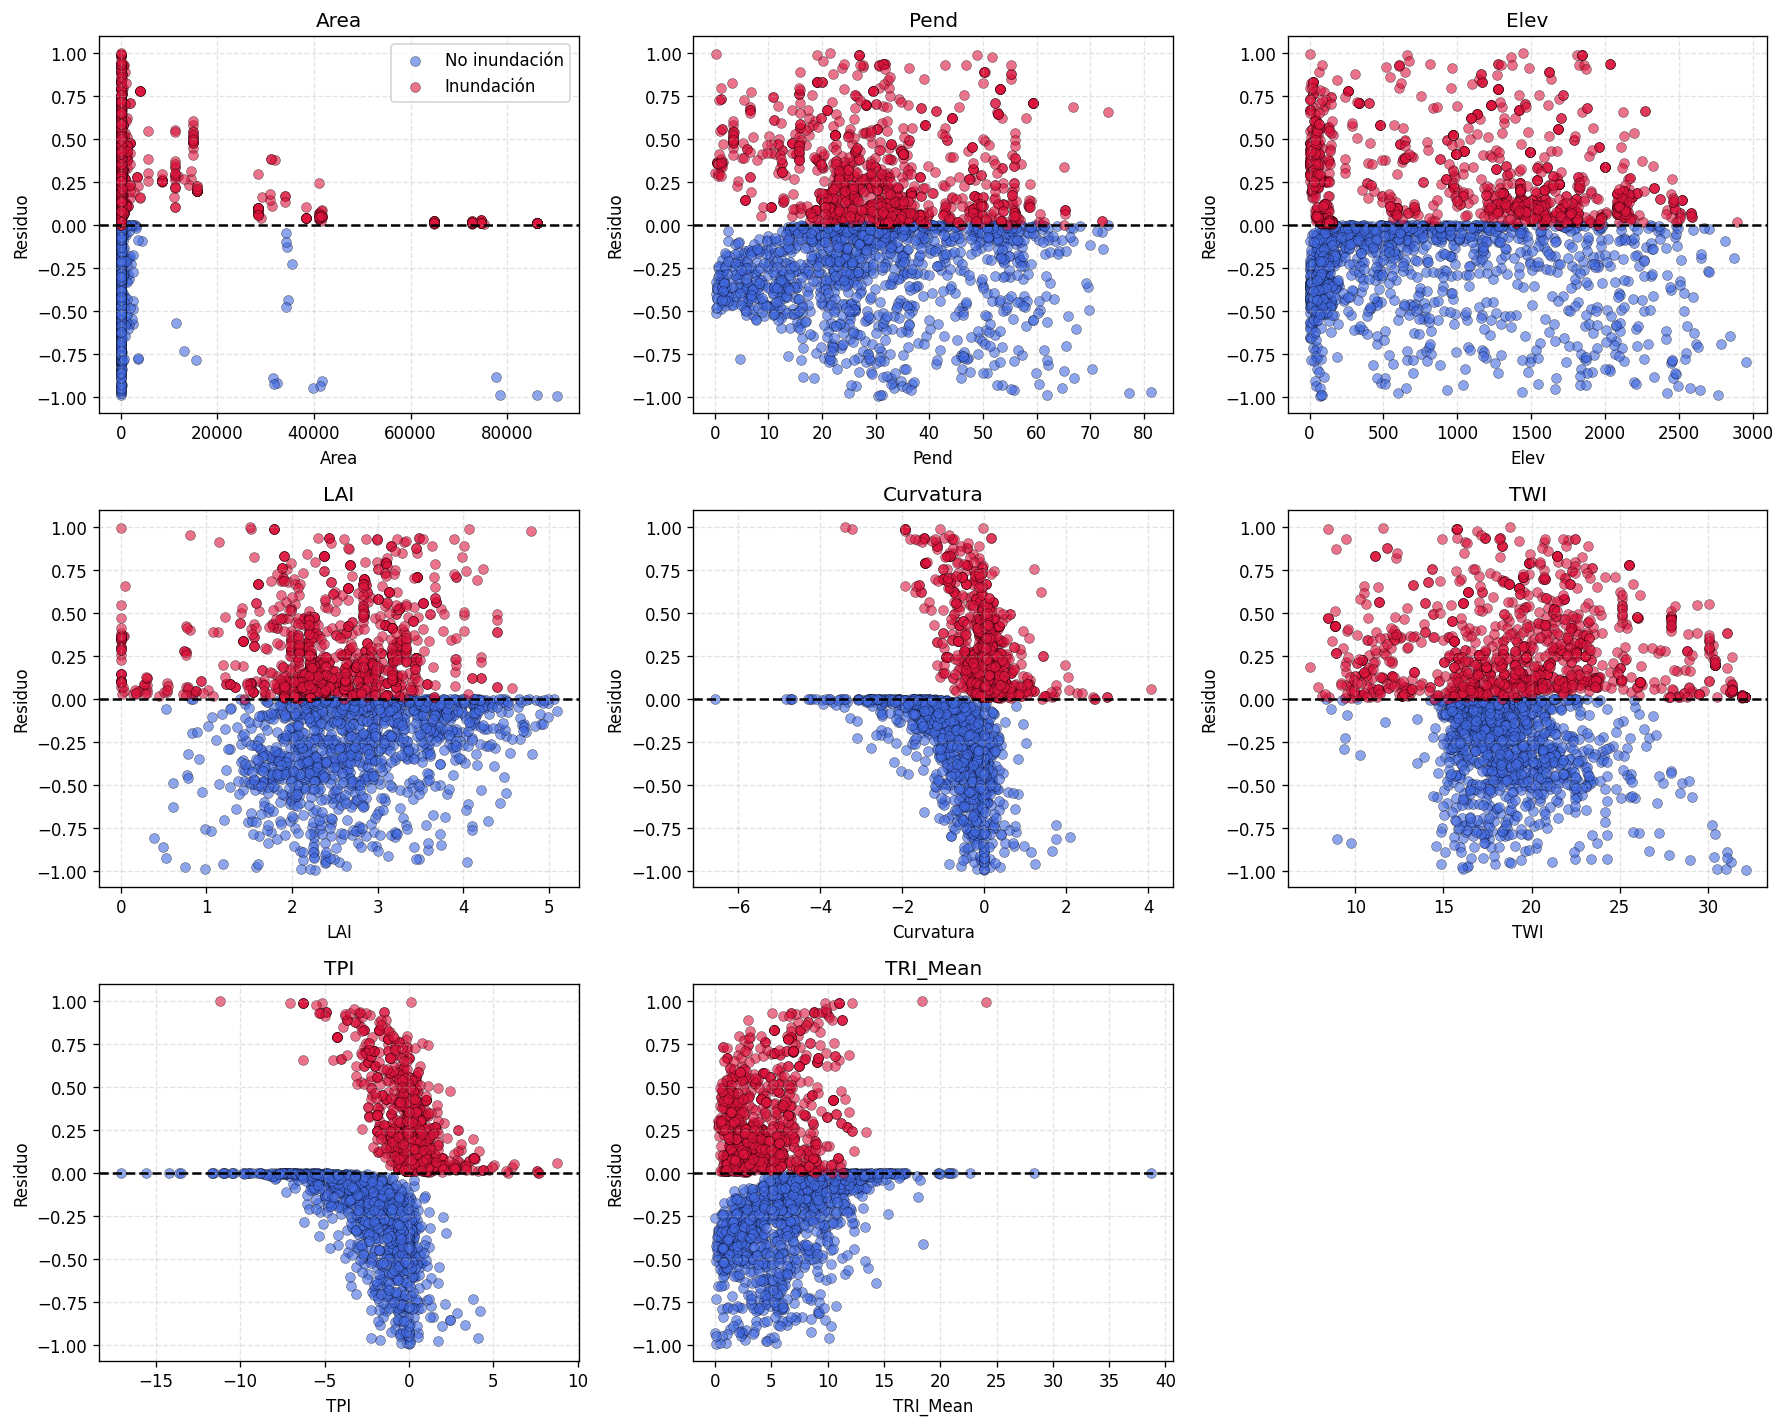

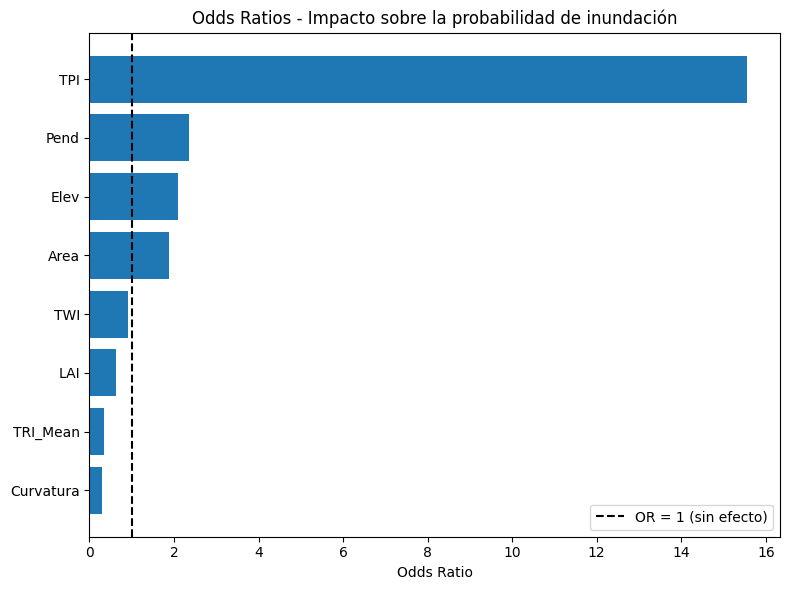

In [17]:
import geopandas as gpd
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# ==========================
# Cargar datos
# ==========================
ruta_shape = r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Puntos\Eventos_y_ausencias_V1.shp"
gdf = gpd.read_file(ruta_shape)
print(gdf["Subregion"].unique())
y = gdf["Inund"]
gdf["log_A"]=np.log(gdf["Area"])


var = [
    "Area",
#    "log_A",
    "Pend",
    "Elev",
    "LAI",
    "Curvatura",
    "TWI",
    "TPI",
#    "TRI",
#    "Curv_Mean",
#    "TPI_Mean",
    "TRI_Mean",
]

df = gdf[["Inund"] + var].replace(-9999, np.nan).dropna()
y = df["Inund"].astype(int)
st = StandardScaler()
X_scaled = st.fit_transform(df[var])
X = sm.add_constant(X_scaled)

model = sm.Logit(y, X).fit()

print(model.summary())

prob = model.predict(X)

auc = roc_auc_score(y, prob)
print("AUC:", auc)

fpr, tpr, thresholds = roc_curve(y, prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()

prob = model.predict(X)

# ==========================
# Predicciones
# ==========================
y_probs = model.predict(X)
y_pred = np.where(y_probs >= 0.5, 1, 0)

# ==========================
# Matriz de confusión
# ==========================
cm = confusion_matrix(y, y_pred)

print("\nMatriz de confusión:")
print(pd.DataFrame(
    cm,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
))

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Real 0", "Real 1"]
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Observado")
plt.tight_layout()
plt.show()

# ==========================
# Curva ROC
# ==========================
fpr, tpr, thresholds = roc_curve(y, y_probs)
auc = roc_auc_score(y, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("AUC:", auc)

# ==========================
# Residuos
# ==========================
residuals = y - y_probs

n_var = len(var)
n_cols = 3
n_rows = int(np.ceil(n_var / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5*n_cols, 4*n_rows),
    dpi=120
)

axes = np.array(axes).flatten()

for i, variable in enumerate(var):

    ax = axes[i]

    # Ausencias
    ax.scatter(
        df.loc[y == 0, variable],
        residuals[y == 0],
        color="royalblue",
        edgecolor="black",
        linewidth=0.3,
        alpha=0.6,
        s=35,
        label="No inundación"
    )

    # Presencias
    ax.scatter(
        df.loc[y == 1, variable],
        residuals[y == 1],
        color="crimson",
        edgecolor="black",
        linewidth=0.3,
        alpha=0.6,
        s=35,
        label="Inundación"
    )

    ax.axhline(
        y=0,
        color="black",
        linestyle="--",
        linewidth=1.5
    )

    ax.set_xlabel(variable)
    ax.set_ylabel("Residuo")
    ax.set_title(variable)

    ax.grid(True, linestyle="--", alpha=0.35)

    # Mostrar la leyenda solo en el primer gráfico
    if i == 0:
        ax.legend(frameon=True)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================
# Odds Ratios
# =====================================
or_df = pd.DataFrame({
    "Variable": var,
    "Coeficiente": model.params[1:],   # omite el intercepto
    "OR": np.exp(model.params[1:]),
    "p": model.pvalues[1:]
})

# Ordenar por Odds Ratio
or_df = or_df.sort_values("OR")

# =====================================
# Gráfica
# =====================================
plt.figure(figsize=(8,6))

plt.barh(or_df["Variable"], or_df["OR"])

plt.axvline(
    1,
    color="black",
    linestyle="--",
    label="OR = 1 (sin efecto)"
)

plt.xlabel("Odds Ratio")
plt.title("Odds Ratios - Impacto sobre la probabilidad de inundación")
plt.legend()

plt.tight_layout()
plt.show()


[None 'ORIENTE' 'SUROESTE' 'BAJO CAUCA' 'URABÁ' 'VALLE DE ABURRÁ' 'NORTE'
 'NORDESTE' 'MAGDALENA MEDIO' 'OCCIDENTE' 'Suroeste' 'Valle de Aburrá'
 'Occidente' 'Norte' 'Urabá' 'Oriente' 'Nordeste' 'Magdalena Medio'
 'Bajo Cauca']
Optimization terminated successfully.
         Current function value: 0.378508
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Inund   No. Observations:                 2529
Model:                          Logit   Df Residuals:                     2521
Method:                           MLE   Df Model:                            7
Date:                Tue, 14 Jul 2026   Pseudo R-squ.:                  0.4539
Time:                        12:34:54   Log-Likelihood:                -957.25
converged:                       True   LL-Null:                       -1752.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err      

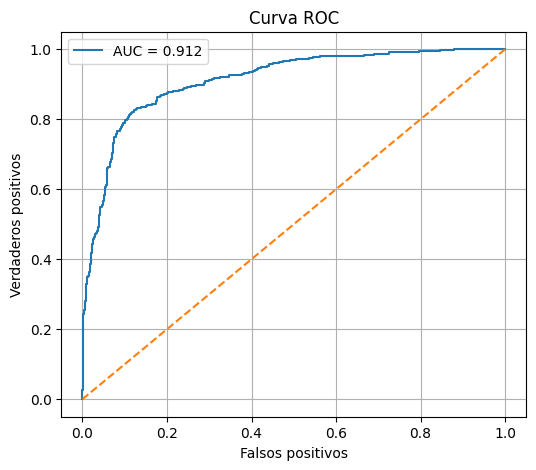


Matriz de confusión:
        Pred 0  Pred 1
Real 0    1056     203
Real 1     201    1069


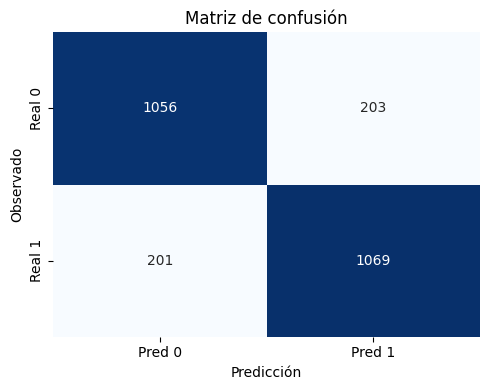

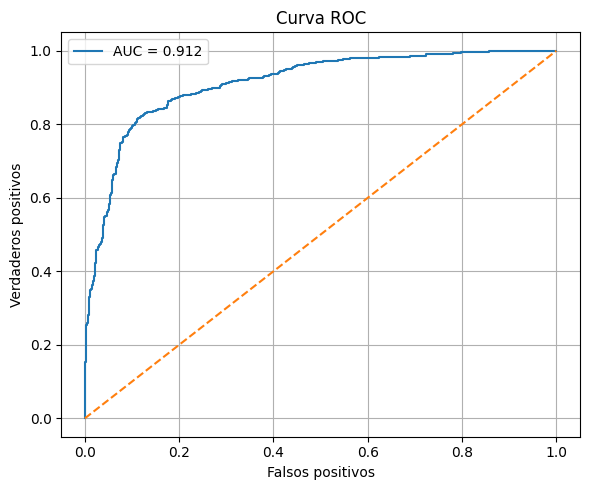

AUC: 0.91182603366001


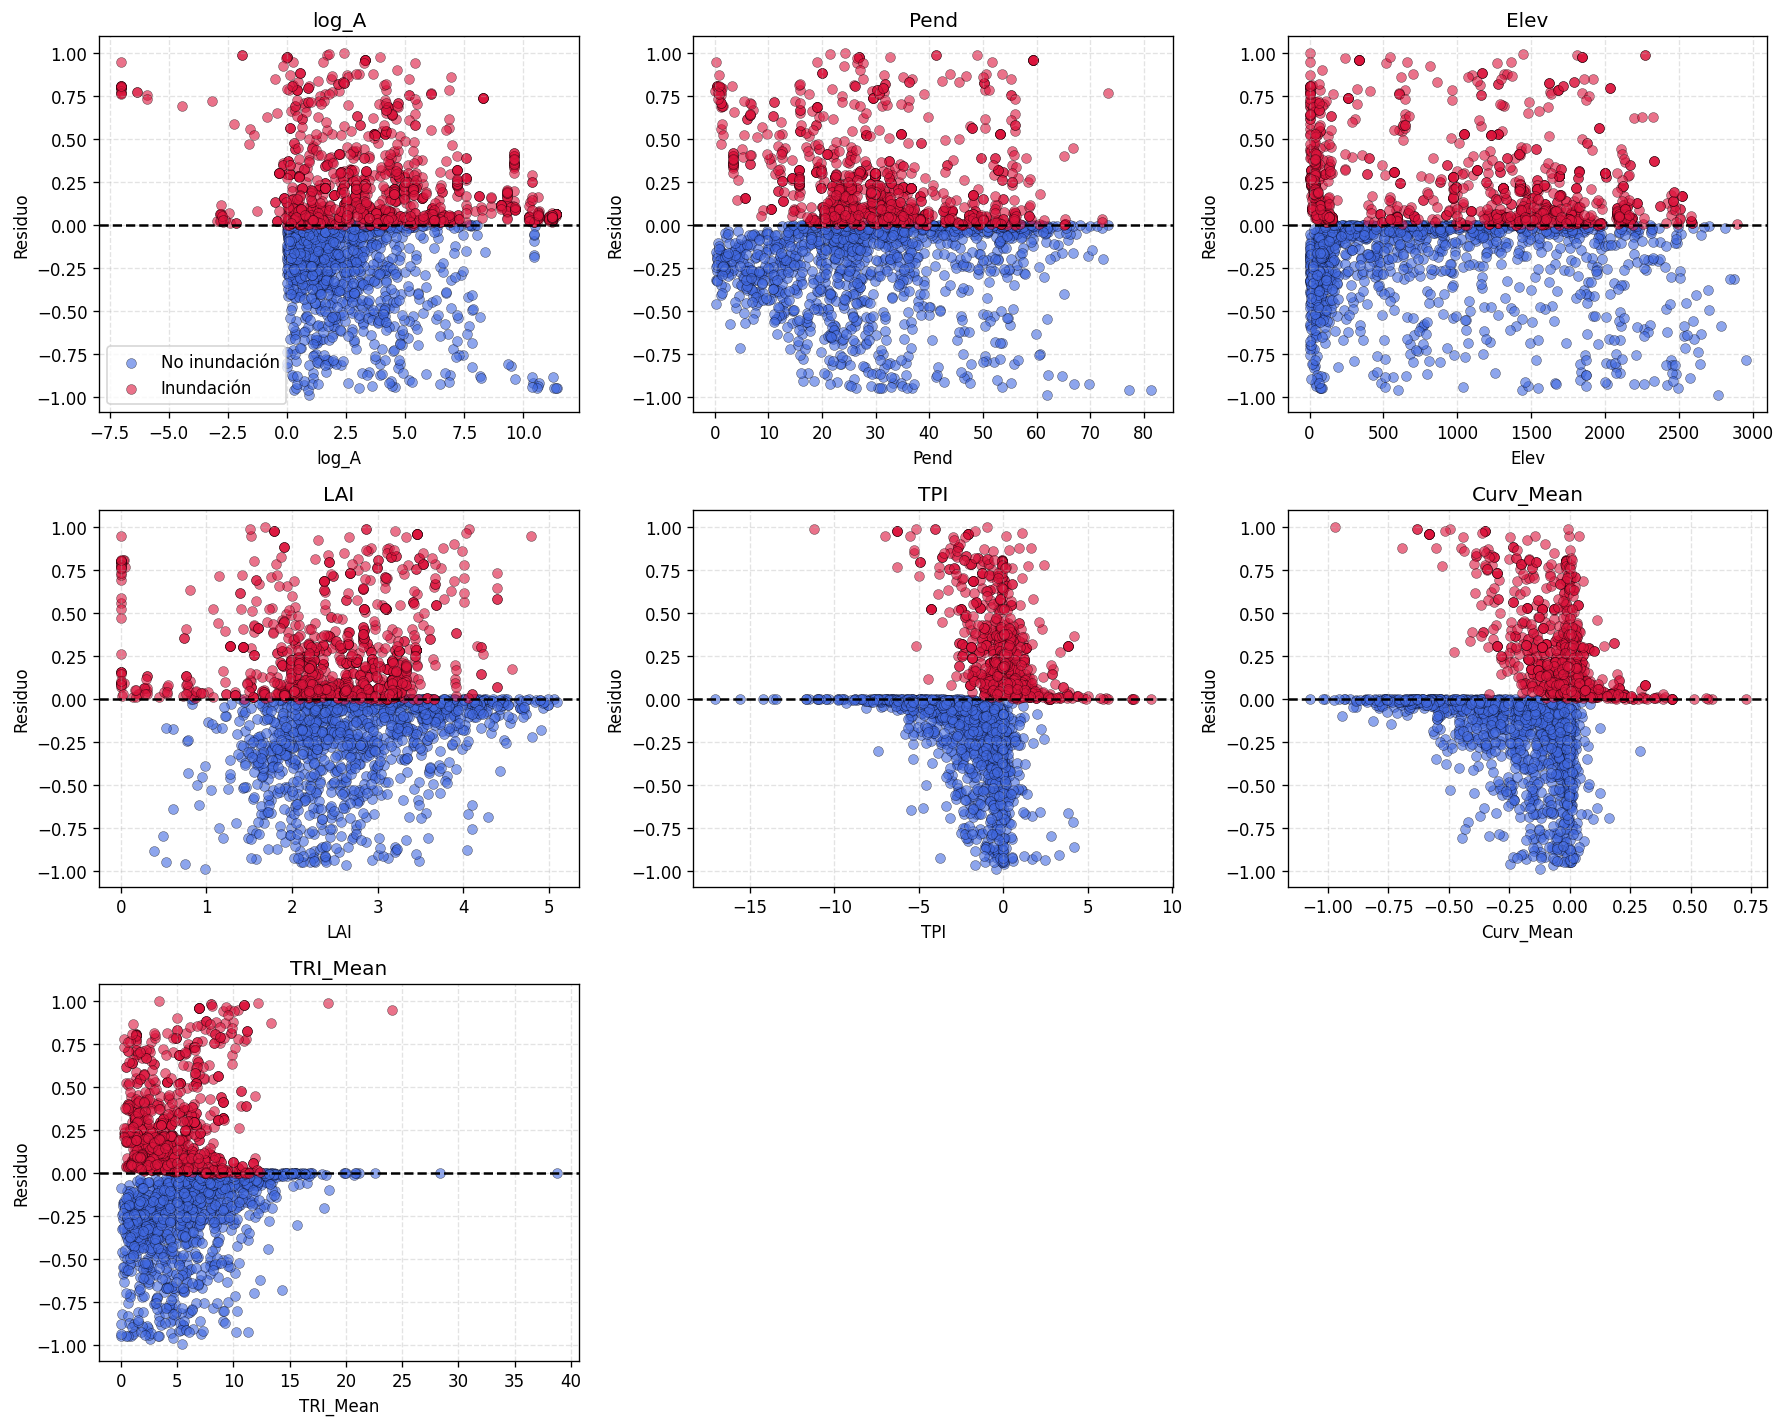

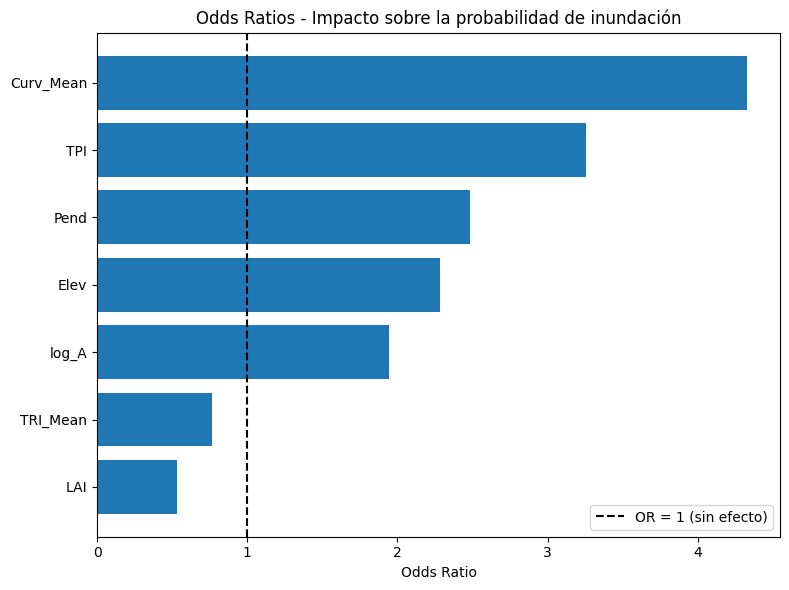

RMSE          : 0.3421
MAE           : 0.2371
R²            : 0.5320
R² adjusted   : 0.5307
AUC           : 0.9118
Accuracy      : 0.8403
Precision     : 0.8404
Recall        : 0.8417
F1-score      : 0.8411
AIC           : 1930.49
BIC           : 1977.18


In [21]:
import geopandas as gpd
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)



# ==========================
# Cargar datos
# ==========================
ruta_shape = r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Puntos\Eventos_y_ausencias_V1.shp"
gdf = gpd.read_file(ruta_shape)
print(gdf["Subregion"].unique())
y = gdf["Inund"]
gdf["log_A"]=np.log(gdf["Area"])

var = [
#    "Area",
    "log_A",
    "Pend",
    "Elev",
    "LAI",
#  "Curvatura",
#    "TWI",
    "TPI",
#    "TRI",
    "Curv_Mean",
#    "TPI_Mean",
    "TRI_Mean"
]

df = gdf[["Inund"] + var].replace(-9999, np.nan).dropna()
y = df["Inund"].astype(int)
st = StandardScaler()
X_scaled = st.fit_transform(df[var])
X = sm.add_constant(X_scaled)

model = sm.Logit(y, X).fit()

print(model.summary())

prob = model.predict(X)

auc = roc_auc_score(y, prob)
print("AUC:", auc)

fpr, tpr, thresholds = roc_curve(y, prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()

prob = model.predict(X)

# ==========================
# Predicciones
# ==========================
y_probs = model.predict(X)
y_pred = np.where(y_probs >= 0.5, 1, 0)

# ==========================
# Matriz de confusión
# ==========================
cm = confusion_matrix(y, y_pred)

print("\nMatriz de confusión:")
print(pd.DataFrame(
    cm,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
))

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Real 0", "Real 1"]
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Observado")
plt.tight_layout()
plt.show()

# ==========================
# Curva ROC
# ==========================
fpr, tpr, thresholds = roc_curve(y, y_probs)
auc = roc_auc_score(y, y_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Falsos positivos")
plt.ylabel("Verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("AUC:", auc)

# ==========================
# Residuos
# ==========================
residuals = y - y_probs

n_var = len(var)
n_cols = 3
n_rows = int(np.ceil(n_var / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5*n_cols, 4*n_rows),
    dpi=120
)

axes = np.array(axes).flatten()

for i, variable in enumerate(var):

    ax = axes[i]

    # Ausencias
    ax.scatter(
        df.loc[y == 0, variable],
        residuals[y == 0],
        color="royalblue",
        edgecolor="black",
        linewidth=0.3,
        alpha=0.6,
        s=35,
        label="No inundación"
    )

    # Presencias
    ax.scatter(
        df.loc[y == 1, variable],
        residuals[y == 1],
        color="crimson",
        edgecolor="black",
        linewidth=0.3,
        alpha=0.6,
        s=35,
        label="Inundación"
    )

    ax.axhline(
        y=0,
        color="black",
        linestyle="--",
        linewidth=1.5
    )

    ax.set_xlabel(variable)
    ax.set_ylabel("Residuo")
    ax.set_title(variable)

    ax.grid(True, linestyle="--", alpha=0.35)

    # Mostrar la leyenda solo en el primer gráfico
    if i == 0:
        ax.legend(frameon=True)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# =====================================
# Odds Ratios
# =====================================
or_df = pd.DataFrame({
    "Variable": var,
    "Coeficiente": model.params[1:],   # omite el intercepto
    "OR": np.exp(model.params[1:]),
    "p": model.pvalues[1:]
})

# Ordenar por Odds Ratio
or_df = or_df.sort_values("OR")

# =====================================
# Gráfica
# =====================================
plt.figure(figsize=(8,6))

plt.barh(or_df["Variable"], or_df["OR"])

plt.axvline(
    1,
    color="black",
    linestyle="--",
    label="OR = 1 (sin efecto)"
)

plt.xlabel("Odds Ratio")
plt.title("Odds Ratios - Impacto sobre la probabilidad de inundación")
plt.legend()

plt.tight_layout()
plt.show()

# ==========================
# Predicciones
# ==========================
y_probs = model.predict(X)
y_pred = (y_probs >= 0.5).astype(int)

# ==========================
# Guardar en el GeoDataFrame
# ==========================
gdf["Prob_pred"] = np.nan
gdf["Pred"] = np.nan
gdf["Residuo"] = np.nan
gdf["Residuo_abs"] = np.nan

gdf.loc[df.index, "Prob_pred"] = y_probs
gdf.loc[df.index, "Pred"] = y_pred
gdf.loc[df.index, "Residuo"] = y - y_probs
gdf.loc[df.index, "Residuo_abs"] = np.abs(y - y_probs)

# ==========================
# Métricas de ajuste
# ==========================
rmse = np.sqrt(mean_squared_error(y, y_probs))
mae = mean_absolute_error(y, y_probs)
r2 = r2_score(y, y_probs)
n = len(y_pred)              # número de observaciones
p = len(var)    # número de variables predictoras usadas en el modelo

r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

auc = roc_auc_score(y, y_probs)
acc = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

# ==========================
# Resultados
# ==========================
print(f"RMSE          : {rmse:.4f}")
print(f"MAE           : {mae:.4f}")
print(f"R²            : {r2:.4f}")
print(f"R² adjusted   : {r2_ajustado:.4f}")
print(f"AUC           : {auc:.4f}")
print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-score      : {f1:.4f}")
print(f"AIC           : {model.aic:.2f}")
print(f"BIC           : {model.bic:.2f}")

RMSE          : 0.3310
MAE           : 0.2234
R²            : 0.5616
R² adjusted   : 0.5602
AUC           : 0.9218
Accuracy      : 0.8632
Precision     : 0.8565
Recall        : 0.8740
F1-score      : 0.8652
AIC           : 1837.40
BIC           : 1889.92


C:\Users\juand\AppData\Local\Temp\ipykernel_24180\1453457990.py:32: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ausencias.plot(
C:\Users\juand\AppData\Local\Temp\ipykernel_24180\1453457990.py:43: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  eventos.plot(
c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\.venv\Lib\site-packages\contextily\tile.py:662: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 13).
  warnings.warn(msg)
C:\Users\juand\AppData\Local\Temp\ipykernel_24180\1453457990.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(


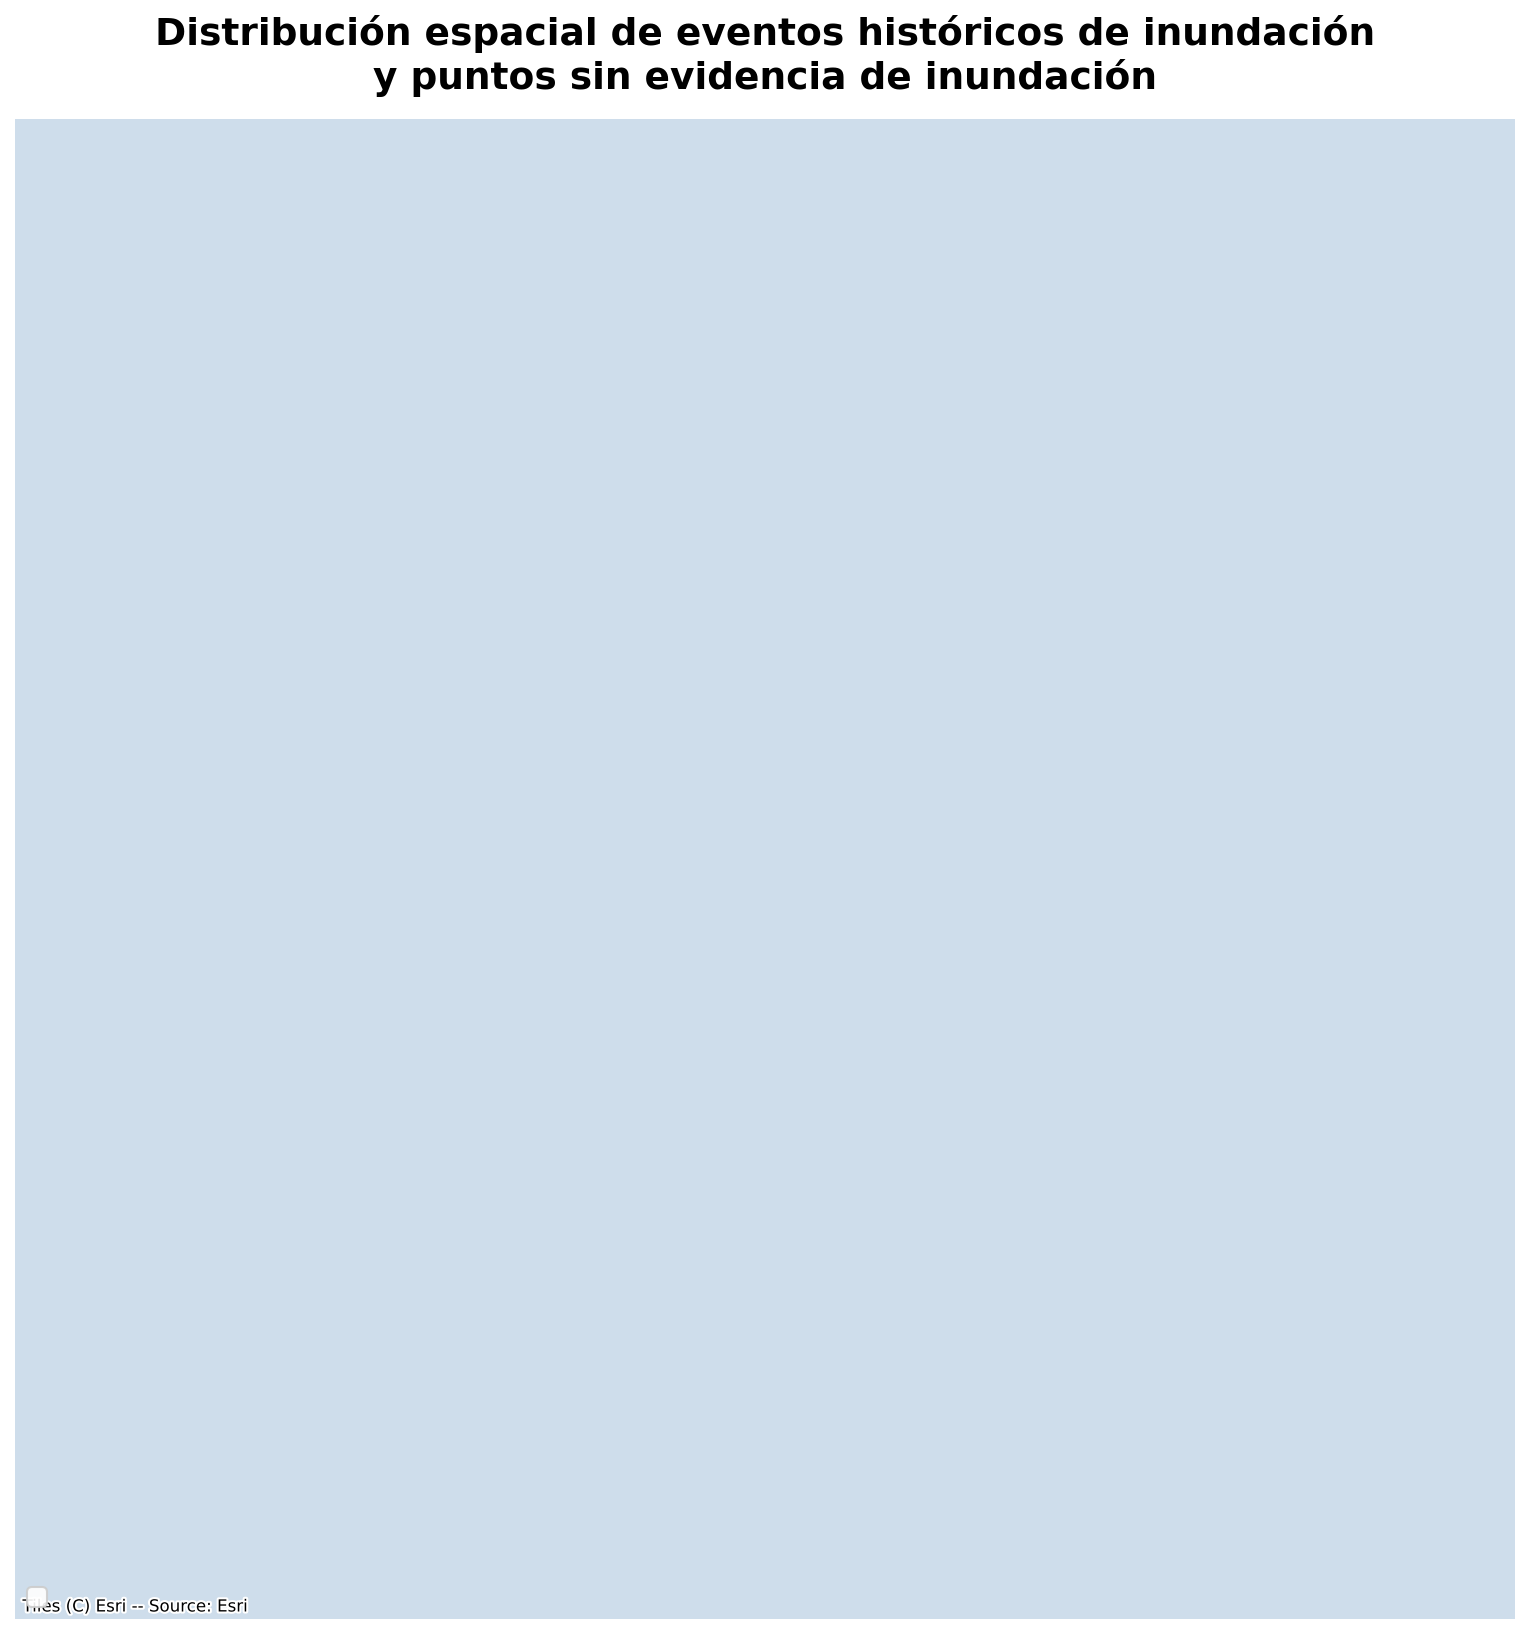

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# ==========================
# Leer shapefile
# ==========================
ruta_shape = r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Puntos\Eventos_y_ausencias_V1.shp"

gdf = gpd.read_file(ruta_shape)
gdf = gdf.to_crs(epsg=4326)
gdf = gdf.to_crs(epsg=3857)

# ==========================
# Proyectar para mapa base
# ==========================
gdf_web = gdf.to_crs(epsg=3857)

# Separar clases
eventos = gdf_web[gdf_web["Inund"] == 1]
ausencias = gdf_web[gdf_web["Inund"] == 0]

# ==========================
# Figura
# ==========================
fig, ax = plt.subplots(
    figsize=(11, 11),
    dpi=150
)

# Ausencias
ausencias.plot(
    ax=ax,
    color="#2C7FB8",
    markersize=18,
    alpha=0.60,
    edgecolor="white",
    linewidth=0.25,
    label="No inundación"
)

# Eventos
eventos.plot(
    ax=ax,
    color="#D7191C",
    markersize=22,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.30,
    label="Evento histórico"
)

# Mapa base
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldShadedRelief,
    zoom="auto",
    reset_extent=False,
    alpha=0.5,
    zorder=0
)



# ==========================
# Formato
# ==========================
ax.set_title(
    "Distribución espacial de eventos históricos de inundación\n"
    "y puntos sin evidencia de inundación",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_axis_off()

leg = ax.legend(
    loc="lower left",
    fontsize=12,
    frameon=True
)

leg.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()